In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split
import matplotlib.pyplot as plt

In [2]:
# Import Dataset
transform = transforms.ToTensor() # transform will normalize

train_dataset = torchvision.datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)


In [3]:
# Split training set to training and validation set
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_datset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

# Create loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [4]:
# Baseline CNN Model
# Model depth is: 2 conv. layers + 2 fully connected layers
# Kernel size is 3x3 for both conv. layers
# Loss function is CrossEntropyLoss (designed for multi-class classification)
# Optimizer is Adam(lr=0.001) bc it automatically adjusts learning rate
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolution layers and Pooling
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 5 * 5, 128)

        # Output Layer (1-10 based on category)
        self.fc2 = nn.Linear(128, 10)

    # How data moves through model
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flattening
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
# Functions to train model and plot losses
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # Training
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # Validation
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
        )

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accuracies,
        "val_acc": val_accuracies,
    }

    return model, history

# Function to plot loss curve
def plot_loss_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


Epoch [1/10] Train Loss: 0.5318 | Train Acc: 0.8068 | Val Loss: 0.3874 | Val Acc: 0.8592
Epoch [2/10] Train Loss: 0.3390 | Train Acc: 0.8774 | Val Loss: 0.3119 | Val Acc: 0.8870
Epoch [3/10] Train Loss: 0.2902 | Train Acc: 0.8930 | Val Loss: 0.2717 | Val Acc: 0.8999
Epoch [4/10] Train Loss: 0.2586 | Train Acc: 0.9052 | Val Loss: 0.2400 | Val Acc: 0.9140
Epoch [5/10] Train Loss: 0.2344 | Train Acc: 0.9143 | Val Loss: 0.2183 | Val Acc: 0.9203
Epoch [6/10] Train Loss: 0.2127 | Train Acc: 0.9212 | Val Loss: 0.2022 | Val Acc: 0.9253
Epoch [7/10] Train Loss: 0.1965 | Train Acc: 0.9280 | Val Loss: 0.1904 | Val Acc: 0.9304
Epoch [8/10] Train Loss: 0.1804 | Train Acc: 0.9332 | Val Loss: 0.1632 | Val Acc: 0.9392
Epoch [9/10] Train Loss: 0.1633 | Train Acc: 0.9392 | Val Loss: 0.1472 | Val Acc: 0.9461
Epoch [10/10] Train Loss: 0.1515 | Train Acc: 0.9434 | Val Loss: 0.1351 | Val Acc: 0.9522


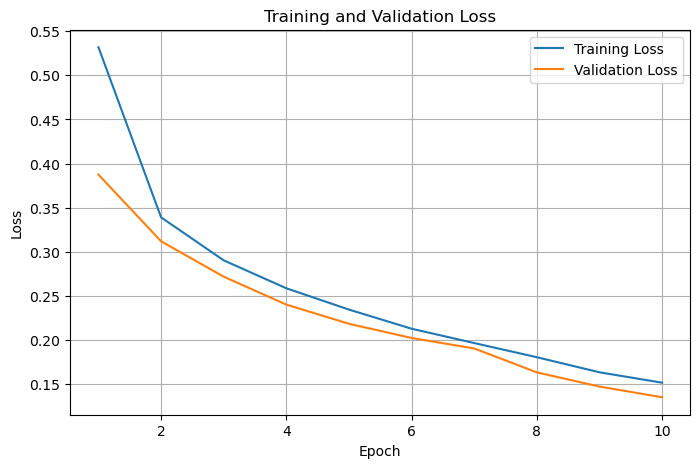

In [6]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    lr=0.001
)

plot_loss_curves(history)

In [7]:
# Function to evaluate model on test set
def evaluate_model(model, test_loader, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    model.to(device)

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    print(f"Test Accuracy: {accuracy:.4f}")

    return accuracy, all_preds, all_labels

# Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix_normalized(all_labels, all_preds, class_names):
    cm = confusion_matrix(all_labels, all_preds)
    cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="RdPu",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Normalized Confusion Matrix")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

Test Accuracy: 0.9124


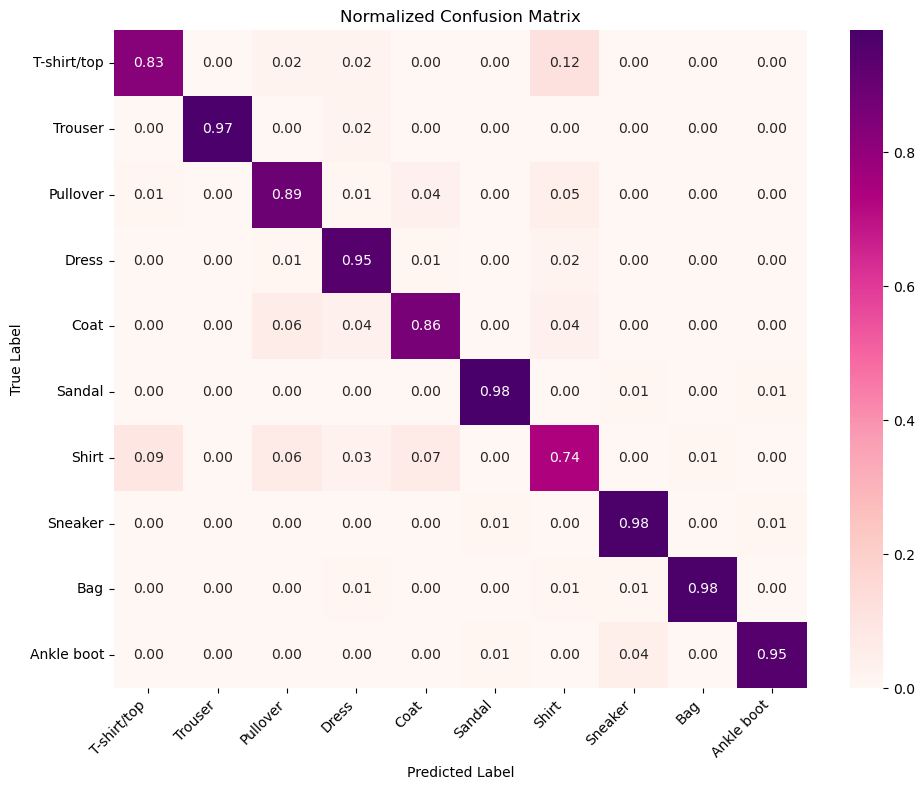

In [8]:
accuracy, preds, labels = evaluate_model(model, test_loader)
class_names = test_loader.dataset.classes
plot_confusion_matrix_normalized(labels, preds, class_names)


In [9]:
# Create CNN with droupout
# randomly turns off some neurons during training to reduce overfitting
class CNN_Dropout(nn.Module):
    def __init__(self):
        super(CNN_Dropout, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
        

Epoch [1/10] Train Loss: 0.6271 | Train Acc: 0.7714 | Val Loss: 0.3947 | Val Acc: 0.8591
Epoch [2/10] Train Loss: 0.4230 | Train Acc: 0.8484 | Val Loss: 0.3284 | Val Acc: 0.8794
Epoch [3/10] Train Loss: 0.3698 | Train Acc: 0.8686 | Val Loss: 0.2972 | Val Acc: 0.8922
Epoch [4/10] Train Loss: 0.3373 | Train Acc: 0.8791 | Val Loss: 0.2635 | Val Acc: 0.9032
Epoch [5/10] Train Loss: 0.3123 | Train Acc: 0.8878 | Val Loss: 0.2478 | Val Acc: 0.9087
Epoch [6/10] Train Loss: 0.2931 | Train Acc: 0.8941 | Val Loss: 0.2339 | Val Acc: 0.9153
Epoch [7/10] Train Loss: 0.2731 | Train Acc: 0.9007 | Val Loss: 0.2135 | Val Acc: 0.9207
Epoch [8/10] Train Loss: 0.2602 | Train Acc: 0.9058 | Val Loss: 0.2039 | Val Acc: 0.9253
Epoch [9/10] Train Loss: 0.2492 | Train Acc: 0.9081 | Val Loss: 0.1949 | Val Acc: 0.9257
Epoch [10/10] Train Loss: 0.2375 | Train Acc: 0.9126 | Val Loss: 0.1826 | Val Acc: 0.9347
Test Accuracy: 0.9050
Test Accuracy: 0.9050


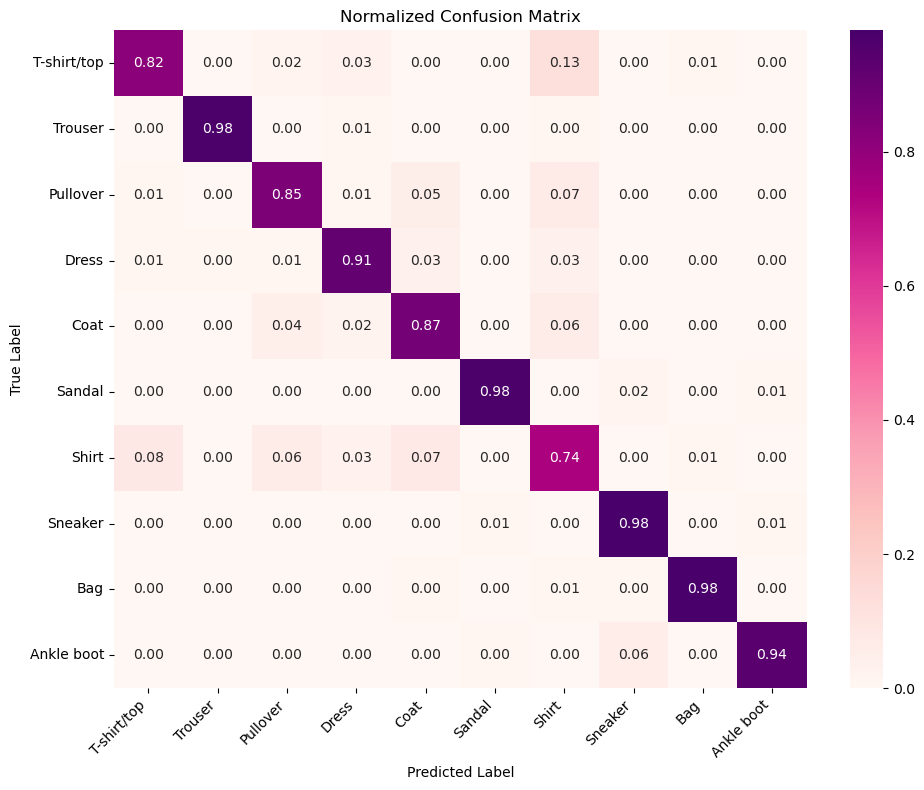

In [10]:
# Create dropout model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dropout_model = CNN_Dropout().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(dropout_model.parameters(), lr=0.001)

# Train model
model, history = train_model(
    model=dropout_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    lr=0.001
)

# Evaluate on test set
dropout_test_acc = evaluate_model(dropout_model, test_loader, device)
accuracy, preds, labels = evaluate_model(dropout_model, test_loader)
plot_confusion_matrix_normalized(labels, preds, class_names)


In [11]:
# Batch Normalization CNN
class CNN_BatchNorm(nn.Module):
    def __init__(self):
        super(CNN_BatchNorm, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn2 = nn.BatchNorm2d(64)

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Epoch [1/10] Train Loss: 0.3936 | Train Acc: 0.8573 | Val Loss: 0.2969 | Val Acc: 0.8946
Epoch [2/10] Train Loss: 0.2799 | Train Acc: 0.8962 | Val Loss: 0.2554 | Val Acc: 0.9042
Epoch [3/10] Train Loss: 0.2418 | Train Acc: 0.9095 | Val Loss: 0.2173 | Val Acc: 0.9194
Epoch [4/10] Train Loss: 0.2113 | Train Acc: 0.9204 | Val Loss: 0.1984 | Val Acc: 0.9282
Epoch [5/10] Train Loss: 0.1918 | Train Acc: 0.9275 | Val Loss: 0.1959 | Val Acc: 0.9258
Epoch [6/10] Train Loss: 0.1691 | Train Acc: 0.9367 | Val Loss: 0.1436 | Val Acc: 0.9490
Epoch [7/10] Train Loss: 0.1519 | Train Acc: 0.9427 | Val Loss: 0.1306 | Val Acc: 0.9511
Epoch [8/10] Train Loss: 0.1340 | Train Acc: 0.9495 | Val Loss: 0.1585 | Val Acc: 0.9383
Epoch [9/10] Train Loss: 0.1187 | Train Acc: 0.9549 | Val Loss: 0.1146 | Val Acc: 0.9583
Epoch [10/10] Train Loss: 0.1070 | Train Acc: 0.9594 | Val Loss: 0.0953 | Val Acc: 0.9658
Test Accuracy: 0.9122
Test Accuracy: 0.9122


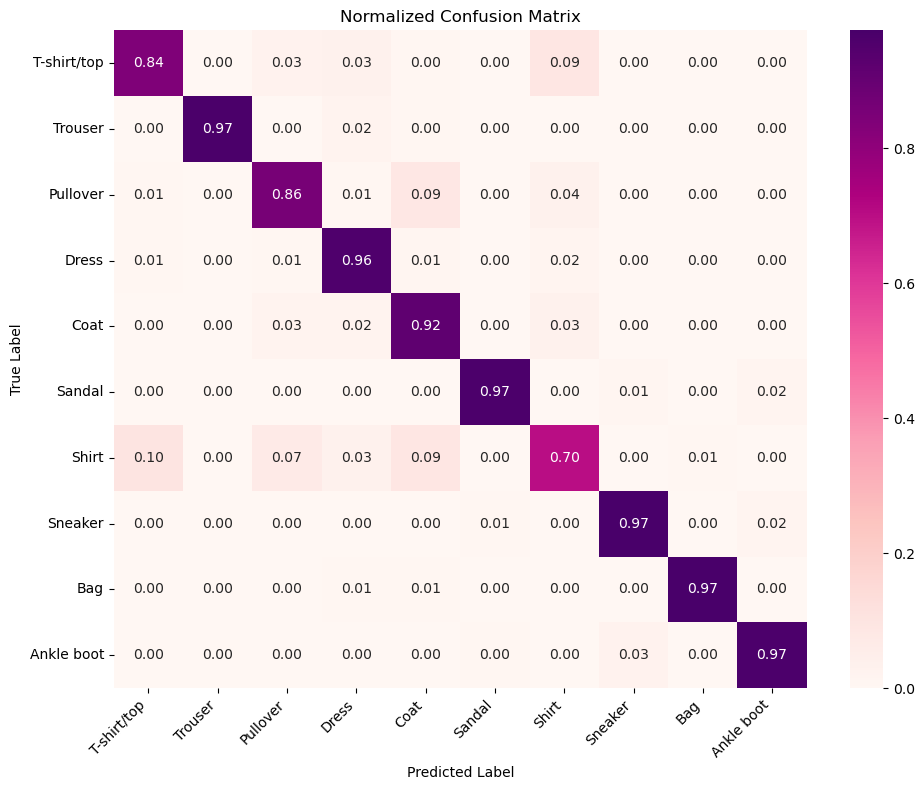

In [12]:
# Create batch normalization model
batchnorm_model = CNN_BatchNorm().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(batchnorm_model.parameters(), lr=0.001)

# Train model
model, history = train_model(
    model=batchnorm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    lr=0.001
)

# Evaluate on test set
batchnorm_test_acc = evaluate_model(batchnorm_model, test_loader, device)
accuracy, preds, labels = evaluate_model(batchnorm_model, test_loader)
plot_confusion_matrix_normalized(labels, preds, class_names)